# Numerical reproduction using Finite Difference Method: Evolution of Stress within a Spherical Insertion Electrode Particle



In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
def solve_diffusion(Nx=200, tmax=0.5, Nt=100, bc_type='potentiostatic'):
    dx = 1.0/Nx
    dt = tmax/Nt
    s = dt/(2.0*dx**2)
    A = np.zeros((Nx+1,Nx+1))
    B = np.zeros((Nx+1,Nx+1))
    A[0,0]=1+6*s
    A[0,1]=-6*s
    B[0,0]=1-6*s
    B[0,1]=6*s
    for i in range(1,Nx):
        A[i,i-1]=-s*(i-1)/i
        A[i,i]=1+2*s
        A[i,i+1]=-s*(i+1)/i
        B[i,i-1]= s*(i-1)/i
        B[i,i]=1-2*s
        B[i,i+1]= s*(i+1)/i
    if bc_type=='potentiostatic':
        A[Nx,Nx]=1.0
    else:
        A[Nx,Nx-1]=-2*s
        A[Nx,Nx]=1+2*s
        B[Nx,Nx-1]=2*s
        B[Nx,Nx]=1-2*s
        galv_const = 2*(Nx+1)*dt/(Nx*dx)
    c_n = np.zeros(Nx+1)
    c=[c_n]
    for n in range(Nt+1):
        rhs = B@c_n
        if bc_type=='potentiostatic':
          rhs[Nx]=1.0
        else: rhs[Nx] += galv_const
        c_n = np.linalg.solve(A, rhs)
        c.append(c_n)
    return c

In [58]:
def compute_c_avg(x, c):
    c_avg = np.zeros_like(c)
    c_avg[0] = c[0]
    for j in range(1, len(x)):
        integrand = x[:j+1]**2 * c[:j+1]
        c_avg[j] = 3.0/x[j]**3 * np.trapezoid(integrand, x[:j+1])
    return c_avg

def compute_stresses(x, c):
    c_avg = compute_c_avg(x, c)
    sig_r = (2.0/3.0)*(c_avg[-1] - c_avg)
    sig_t = (1.0/3.0)*(2.0*c_avg[-1] + c_avg - 3.0*c)
    return sig_r, sig_t

def compute_shear(sig_r, sig_t):
    return (sig_r - sig_t) / 2.0

def compute_strain_energy(x, sig_r, sig_t, nu):
    integrand = (sig_r**2 + 2*sig_t**2 - 2*nu*sig_t*(2*sig_r+sig_t)) * x**2
    return np.trapezoid(integrand, x)

##Potentiostatic

In [59]:
Nx=200
Nt=1000
tmax=0.5
c=solve_diffusion(Nx=Nx,tmax=tmax,Nt=Nt,bc_type='potentiostatic')

In [60]:
x=np.linspace(0,1,Nx+1)
Nt_given=10
multiplier=Nt/Nt_given

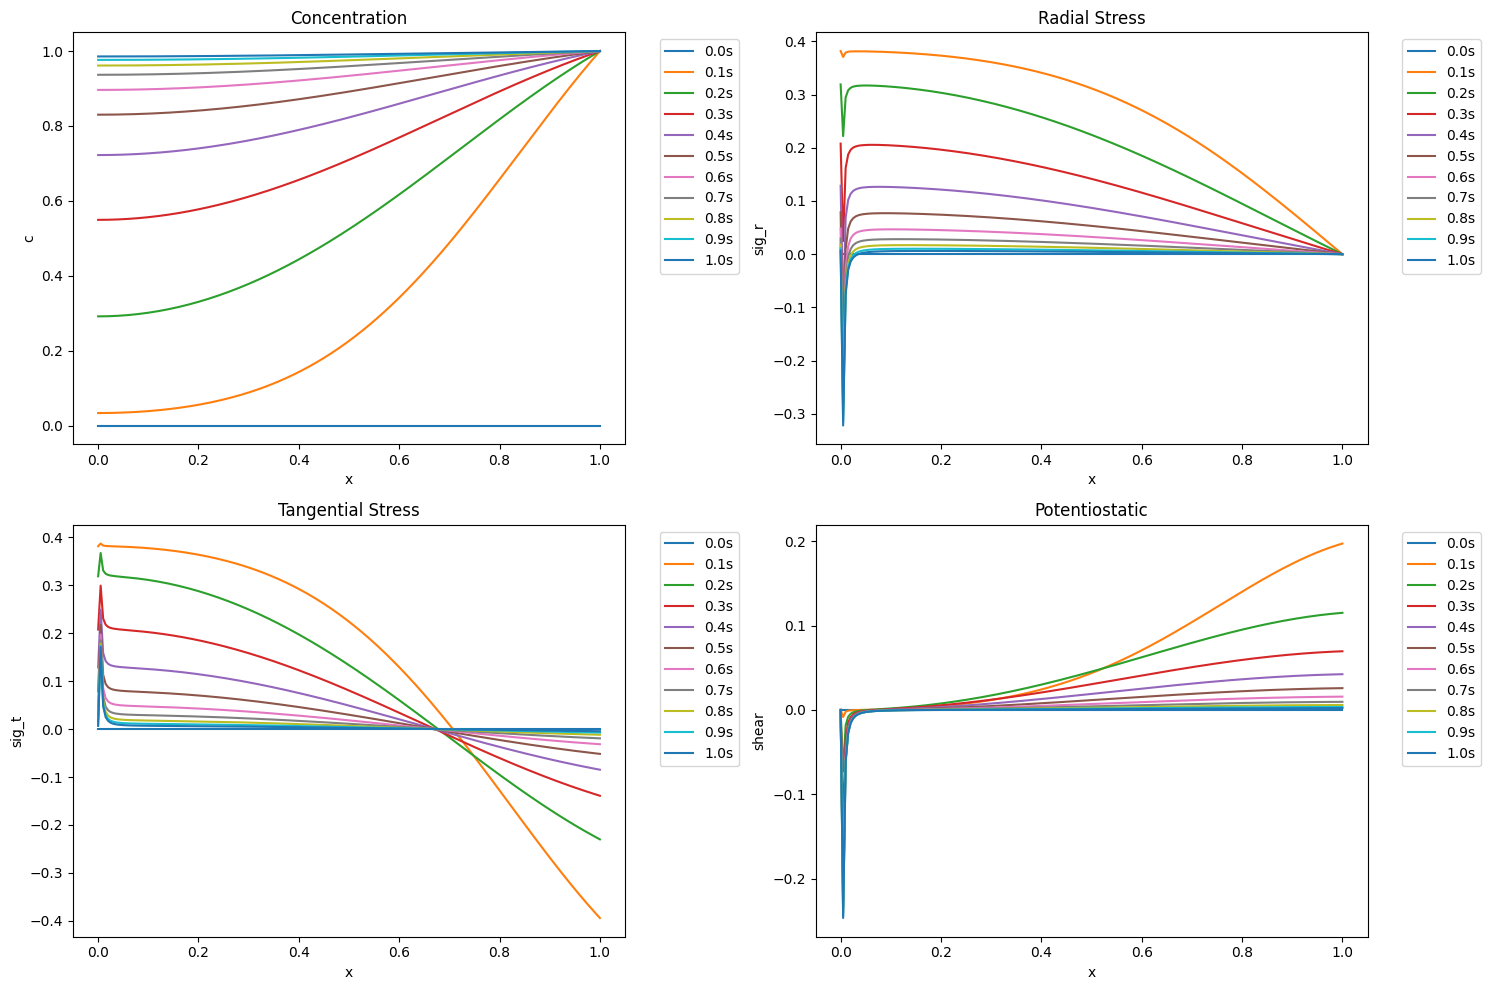

In [61]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    ax[0,0].plot(x,c_n,label=str(n/Nt_given)+'s')
    ax[0,0].set_xlabel('x')
    ax[0,0].set_ylabel('c')
    ax[0,0].set_title('Concentration')
    ax[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    ax[0,1].plot(x,sig_r,label=str(n/Nt_given)+'s')
    ax[0,1].set_xlabel('x')
    ax[0,1].set_ylabel('sig_r')
    ax[0,1].set_title('Radial Stress')
    ax[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    ax[1,0].plot(x,sig_t,label=str(n/Nt_given)+'s')
    ax[1,0].set_xlabel('x')
    ax[1,0].set_ylabel('sig_t')
    ax[1,0].set_title('Tangential Stress')
    ax[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    shear = compute_shear(sig_r, sig_t)
    ax[1,1].plot(x,shear,label=str(n/Nt_given)+'s')
    ax[1,1].set_xlabel('x')
    ax[1,1].set_ylabel('shear')
    ax[1,1].set_title('Shear Stress')
    ax[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Potentiostatic')
plt.tight_layout()
plt.savefig('fig1.png')

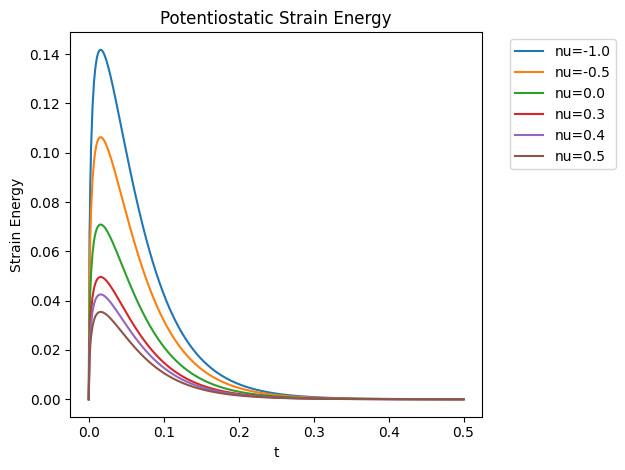

In [62]:
nu_values = [-1.0, -0.5, 0.0, 0.3, 0.4, 0.5]
Nt_given=1000
multiplier=Nt/Nt_given
for nu in nu_values:
  energy_values=[]
  for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    energy=compute_strain_energy(x, sig_r, sig_t, nu)
    energy_values.append(energy)
  plt.plot(np.linspace(0,tmax,Nt_given+1),energy_values,label='nu='+str(nu))
plt.xlabel('t')
plt.ylabel('Strain Energy')
plt.title('Potentiostatic Strain Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig2.png')

##Galvanostatic

In [63]:
c=solve_diffusion(Nx=Nx,tmax=tmax,Nt=Nt,bc_type='galvanostatic')

In [64]:
Nt_given=10
multiplier=Nt/Nt_given

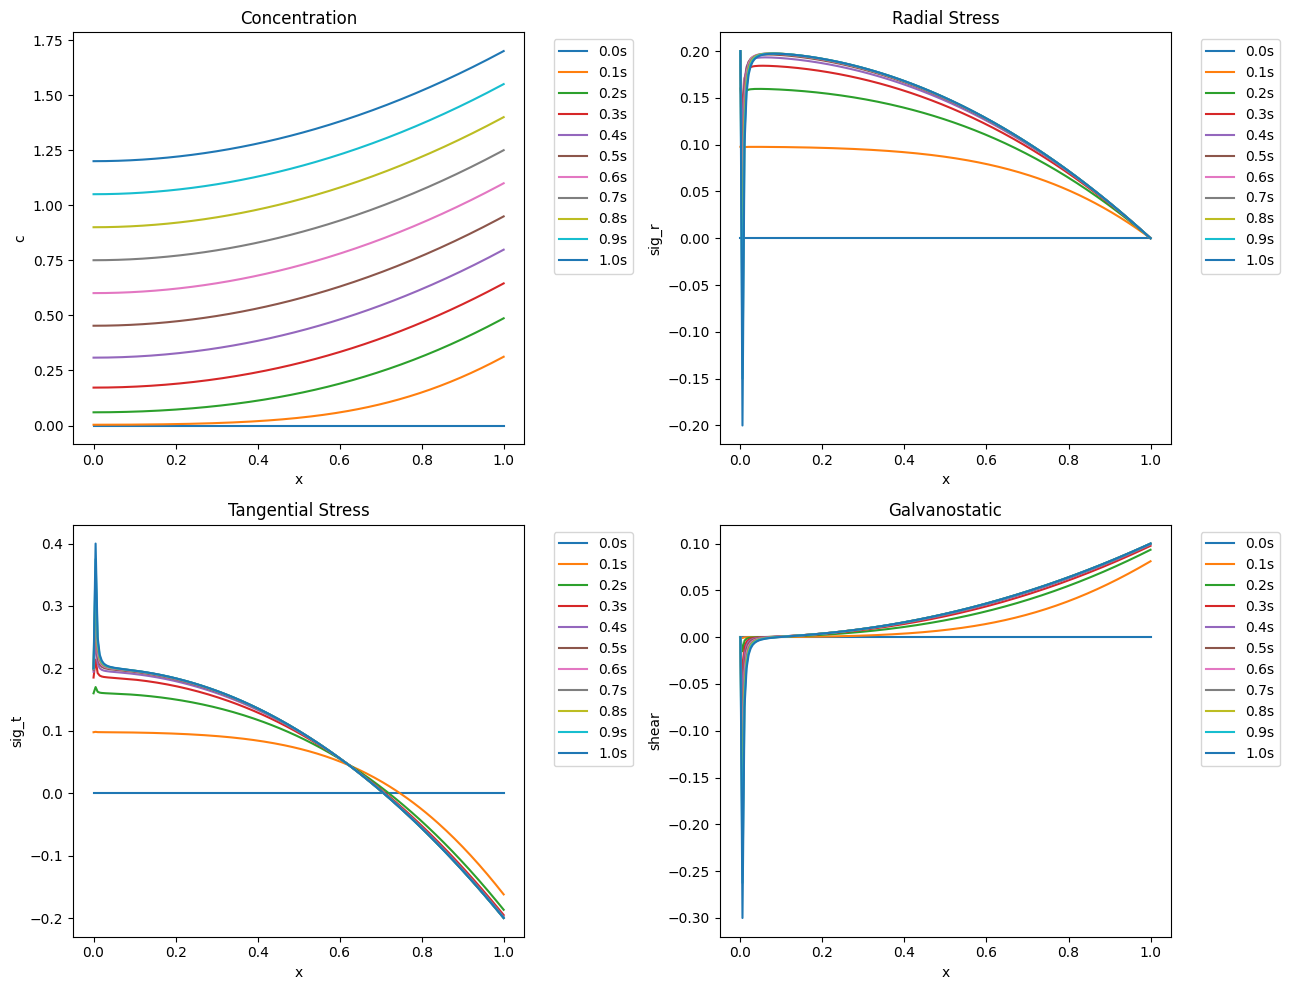

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    ax[0,0].plot(x,c_n,label=str(n/Nt_given)+'s')
    ax[0,0].set_xlabel('x')
    ax[0,0].set_ylabel('c')
    ax[0,0].set_title('Concentration')
    ax[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    ax[0,1].plot(x,sig_r,label=str(n/Nt_given)+'s')
    ax[0,1].set_xlabel('x')
    ax[0,1].set_ylabel('sig_r')
    ax[0,1].set_title('Radial Stress')
    ax[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    ax[1,0].plot(x,sig_t,label=str(n/Nt_given)+'s')
    ax[1,0].set_xlabel('x')
    ax[1,0].set_ylabel('sig_t')
    ax[1,0].set_title('Tangential Stress')
    ax[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    shear = compute_shear(sig_r, sig_t)
    ax[1,1].plot(x,shear,label=str(n/Nt_given)+'s')
    ax[1,1].set_xlabel('x')
    ax[1,1].set_ylabel('shear')
    ax[1,1].set_title('Shear Stress')
    ax[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Galvanostatic')
plt.tight_layout()
plt.savefig('fig3.png')

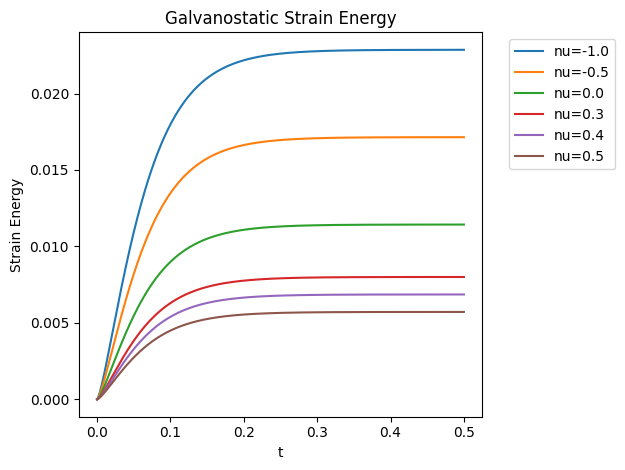

In [66]:
Nt_given=1000
multiplier=Nt/Nt_given
for nu in nu_values:
  energy_values=[]
  for n in range(Nt_given+1):
    c_n=c[int(n*multiplier)]
    sig_r, sig_t = compute_stresses(x, c_n)
    energy=compute_strain_energy(x, sig_r, sig_t, nu)
    energy_values.append(energy)
  plt.plot(np.linspace(0,tmax,Nt_given+1),energy_values,label='nu='+str(nu))
plt.xlabel('t')
plt.ylabel('Strain Energy')
plt.title('Galvanostatic Strain Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig4.png')